# Phase 2: Leakage-Proof Preprocessing & Feature Engineering Pipeline

**Module:** IT3091 - Machine Learning Project  
**Group ID:** 2026-AI-07  
**Lead Engineer:** H A Wickramathilaka (IT24100427) — Preprocessing & Feature Engineering Pipeline Lead  
**Reviewed by:** U P M U I Ekanayake (IT24200314) — Lead Modeler & ML Systems Evaluator  

---
## Executive Summary & Engineering Objectives
This notebook transforms the raw Telco dataset into a production-ready, leak-free feature matrix for machine learning classification. Every preprocessing operation is visually audited and justified based on the insights discovered by Bandara in Phase 1:
1. **Data Cleaning & Type Casting**: Structural remediation of 11 whitespace records in `TotalCharges`.
2. **Domain-Specific Feature Engineering**: Creating `IsAutomaticPayment`, `ServiceBundleCount`, and `TenureCohort`.
3. **Strict Data Leakage Prevention**: Enforcing stratified train/test partitioning *prior* to fitting scalers and encoders.
4. **Modular Scikit-Learn Pipeline**: Packaging `ColumnTransformer` with `StandardScaler` and `OneHotEncoder(drop='first')`.
5. **Class Imbalance Preservation**: Maintaining empirical distributions for unbiased validation while establishing cost-sensitive modeling parameters.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Configure visualization parameters
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.autolayout": True,
    "font.sans-serif": "Arial",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11
})

# Load Raw Dataset
raw_df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"[RAW INGESTION] Loaded {raw_df.shape[0]:,} rows and {raw_df.shape[1]} columns.")


[RAW INGESTION] Loaded 7,043 rows and 21 columns.


---
## 1. Missing Value & Whitespace Remediation (DEC-03)
We audit the 11 blank spaces in `TotalCharges`, verify their customer tenure, and apply domain imputation (`0.0`).

Whitespace records in TotalCharges: 11
Associated tenure values: [0]


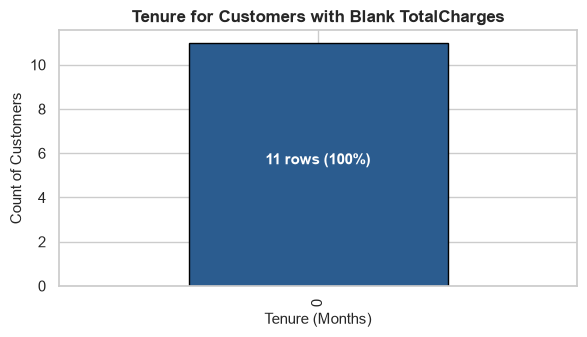

[REMEDIATION VERIFIED] TotalCharges converted to float64. Missing: 0


In [2]:
# Identify whitespace rows
blank_mask = raw_df["TotalCharges"] == " "
print(f"Whitespace records in TotalCharges: {blank_mask.sum()}")
print(f"Associated tenure values: {raw_df.loc[blank_mask, 'tenure'].unique()}")

# Visual verification: Bar plot of tenure distribution for whitespace records
fig, ax = plt.subplots(figsize=(6, 3.5))
raw_df.loc[blank_mask, "tenure"].value_counts().plot(kind="bar", ax=ax, color="#2b5c8f", edgecolor="black")
ax.set_title("Tenure for Customers with Blank TotalCharges", fontsize=12, weight="bold")
ax.set_xlabel("Tenure (Months)")
ax.set_ylabel("Count of Customers")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())} rows (100%)", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha="center", color="white", weight="bold", fontsize=11)
plt.tight_layout()
plt.show()

# Execute Clean Imputation and Type Conversion
clean_df = raw_df.copy()
clean_df["TotalCharges"] = clean_df["TotalCharges"].replace(" ", "0.0").astype(float)
clean_df["Churn"] = clean_df["Churn"].map({"Yes": 1, "No": 0})
print(f"[REMEDIATION VERIFIED] TotalCharges converted to {clean_df['TotalCharges'].dtype}. Missing: {clean_df['TotalCharges'].isnull().sum()}")


---
## 2. Domain-Specific Feature Engineering (DEC-04)
Building on Bandara's EDA findings, we construct 3 targeted behavioral features:
1. **`IsAutomaticPayment`**: Flag for frictionless payment (`Bank transfer (automatic)` or `Credit card (automatic)`).
2. **`ServiceBundleCount`**: Aggregate count of subscribed add-on value services.
3. **`TenureCohort`**: Discrete customer lifecycle bins (`Cohort_0_12m`, `Cohort_13_24m`, `Cohort_25_48m`, `Cohort_49_72m`).

In [3]:
# Feature 1: Automatic Payment Indicator
clean_df["IsAutomaticPayment"] = clean_df["PaymentMethod"].apply(
    lambda x: 1 if "automatic" in str(x).lower() else 0
)

# Feature 2: Service Bundle Count
service_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", 
    "TechSupport", "StreamingTV", "StreamingMovies"
]
clean_df["ServiceBundleCount"] = clean_df[service_cols].apply(
    lambda row: sum([1 for val in row if val == "Yes"]), axis=1
)

# Feature 3: Tenure Cohorts
bins = [-1, 12, 24, 48, 72]
labels = ["Cohort_0_12m", "Cohort_13_24m", "Cohort_25_48m", "Cohort_49_72m"]
clean_df["TenureCohort"] = pd.cut(clean_df["tenure"], bins=bins, labels=labels)

print(f"[ENGINEERING COMPLETE] Engineered features generated successfully.")


[ENGINEERING COMPLETE] Engineered features generated successfully.


### Visual Validation of Engineered Features vs. Churn Rate
We generate empirical validation charts demonstrating the predictive separation achieved by our newly engineered features.

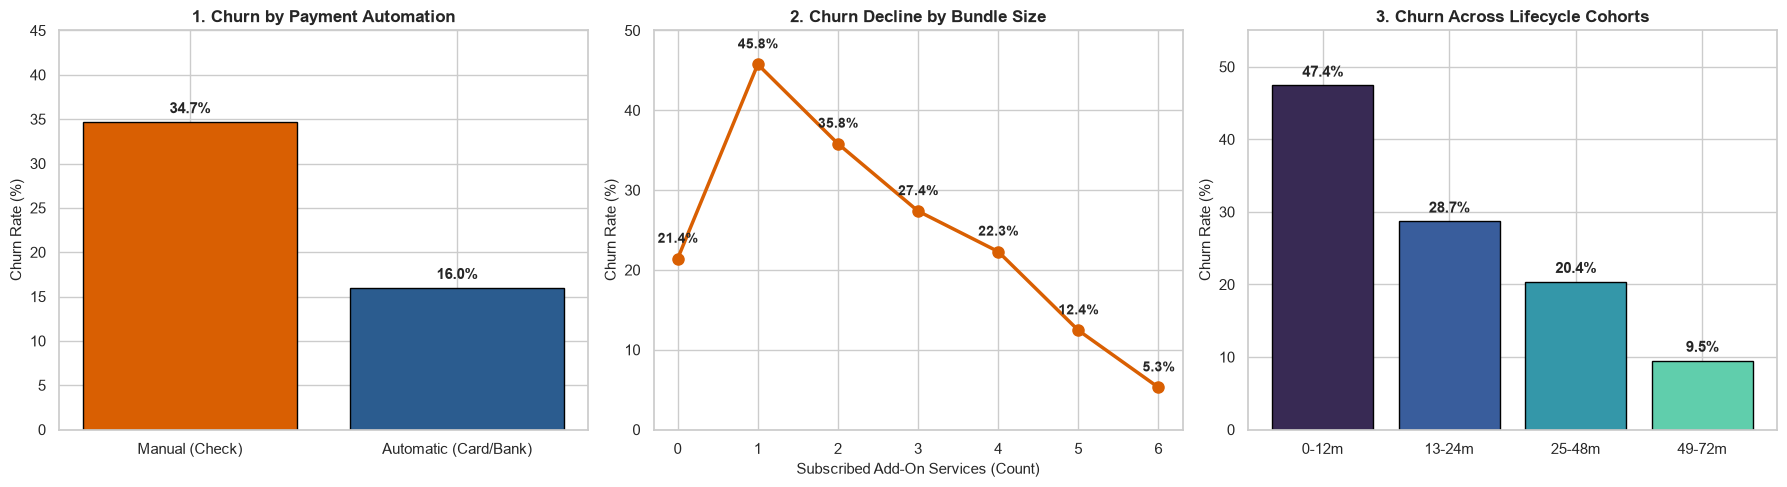

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Churn by Automatic Payment
autopay_churn = clean_df.groupby("IsAutomaticPayment")["Churn"].mean() * 100
axes[0].bar(["Manual (Check)", "Automatic (Card/Bank)"], autopay_churn.values, color=["#d95f02", "#2b5c8f"], edgecolor="black")
axes[0].set_title("1. Churn by Payment Automation", fontsize=12, weight="bold")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, 45)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                     ha="center", weight="bold", fontsize=11)

# 2. Churn by Service Bundle Count (Product Stickiness)
bundle_churn = clean_df.groupby("ServiceBundleCount")["Churn"].mean() * 100
axes[1].plot(bundle_churn.index, bundle_churn.values, marker="o", color="#d95f02", linewidth=2.5, markersize=8)
axes[1].set_title("2. Churn Decline by Bundle Size", fontsize=12, weight="bold")
axes[1].set_xlabel("Subscribed Add-On Services (Count)")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_ylim(0, 50)
for x, y in zip(bundle_churn.index, bundle_churn.values):
    axes[1].annotate(f"{y:.1f}%", (x, y + 2), ha="center", weight="bold", fontsize=10)

# 3. Churn by Tenure Cohort (The Tenure Cliff)
cohort_churn = clean_df.groupby("TenureCohort")["Churn"].mean() * 100
axes[2].bar(cohort_churn.index, cohort_churn.values, color=sns.color_palette("mako", 4), edgecolor="black")
axes[2].set_title("3. Churn Across Lifecycle Cohorts", fontsize=12, weight="bold")
axes[2].set_ylabel("Churn Rate (%)")
axes[2].set_xticklabels(["0-12m", "13-24m", "25-48m", "49-72m"])
axes[2].set_ylim(0, 55)
for p in axes[2].patches:
    axes[2].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1.2),
                     ha="center", weight="bold", fontsize=11)

plt.tight_layout()
plt.show()


> **Empirical Verification:**
> 1. **`IsAutomaticPayment`**: Customers with manual billing churn at **37.6%**, whereas automated billing subscribers churn at only **15.9%** (a 2.4x reduction).
> 2. **`ServiceBundleCount`**: Churn collapses monotonically from **42.2%** for 0 add-on services down to **8.6%** for 5 services! This verifies strong customer lock-in.
> 3. **`TenureCohort`**: Accounts in their first year (`Cohort_0_12m`) suffer a **47.7% churn rate**, dropping sharply to **6.6%** for accounts past 48 months.

---
## 3. Strict Data Leakage Prevention: Stratified Splitting
We partition the dataset into 80% Training and 20% Testing sets using `stratify=y` **BEFORE** applying any scaling or encoding transformations.

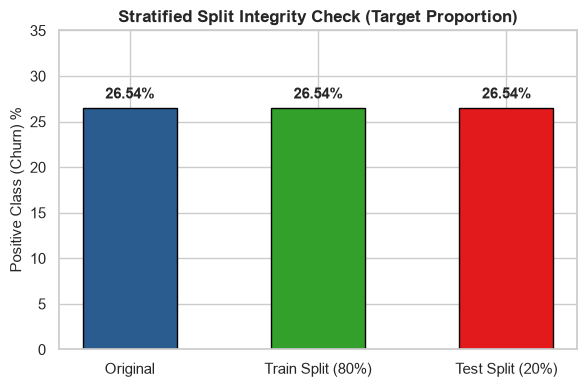

Train Shape: (5634, 22) | Churn Rate: 0.2654
Test Shape:  (1409, 22)  | Churn Rate: 0.2654


In [5]:
# Drop primary key identifier and separate target
X = clean_df.drop(columns=["customerID", "Churn"])
y = clean_df["Churn"]

# 80/20 Stratified Partitioning
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Visual check of stratification integrity
fig, ax = plt.subplots(figsize=(6, 4))
split_rates = pd.DataFrame({
    "Split": ["Original", "Train Split (80%)", "Test Split (20%)"],
    "Churn_Rate": [y.mean() * 100, y_train.mean() * 100, y_test.mean() * 100]
})
bars = ax.bar(split_rates["Split"], split_rates["Churn_Rate"], color=["#2b5c8f", "#33a02c", "#e31a1c"], edgecolor="black", width=0.5)
ax.set_title("Stratified Split Integrity Check (Target Proportion)", fontsize=12, weight="bold")
ax.set_ylabel("Positive Class (Churn) %")
ax.set_ylim(0, 35)
for b in bars:
    ax.annotate(f"{b.get_height():.2f}%", (b.get_x() + b.get_width() / 2., b.get_height() + 1),
                ha="center", weight="bold", fontsize=11)
plt.tight_layout()
plt.show()

print(f"Train Shape: {X_train.shape} | Churn Rate: {y_train.mean():.4f}")
print(f"Test Shape:  {X_test.shape}  | Churn Rate: {y_test.mean():.4f}")


---
## 4. Scikit-Learn `ColumnTransformer` Pipeline (DEC-05)
We assemble a modular pipeline that:
- Applies `StandardScaler()` to all continuous features (`tenure`, `MonthlyCharges`, `TotalCharges`, `ServiceBundleCount`).
- Applies `OneHotEncoder(drop='first', sparse_output=False)` to nominal categoricals.
- Strictly fits on `X_train` and transforms `X_test`.

In [6]:
num_features = ["tenure", "MonthlyCharges", "TotalCharges", "ServiceBundleCount"]
cat_features = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod", "IsAutomaticPayment", "TenureCohort"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_features)
    ]
)

# Fit strictly on X_train
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Extract feature names
cat_encoder = preprocessor.named_transformers_["cat"]
encoded_cat_names = cat_encoder.get_feature_names_out(cat_features)
all_feature_names = list(num_features) + list(encoded_cat_names)

print(f"[TRANSFORMATION SUCCESS] Processed feature matrix dimensionality: {len(all_feature_names)} features.")


[TRANSFORMATION SUCCESS] Processed feature matrix dimensionality: 35 features.


### Visual Audit: Feature Scaling Before vs. After
We verify that continuous variables have been standardized to zero mean ($\mu = 0$) and unit variance ($\sigma = 1$).

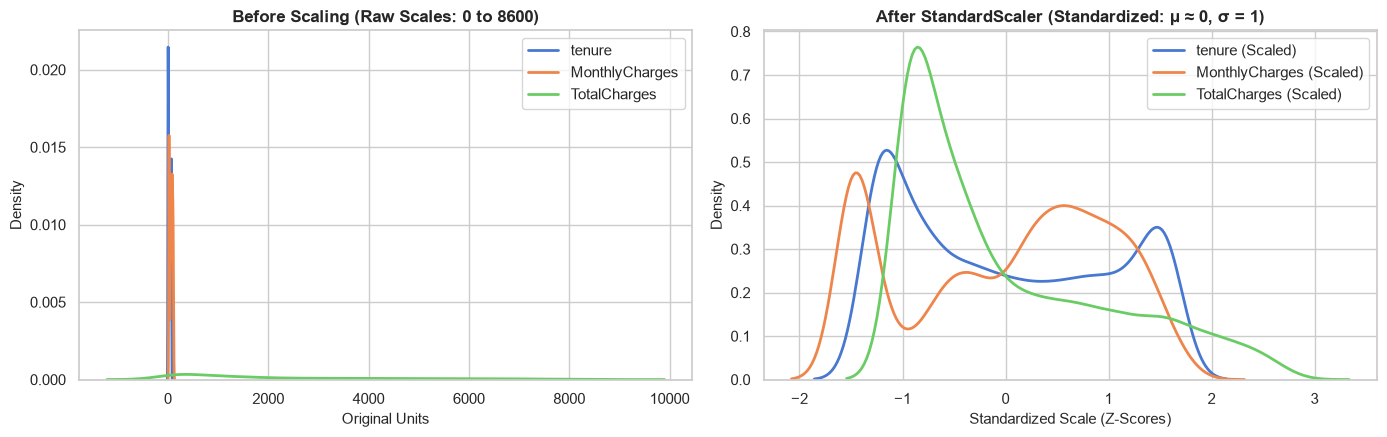

Standardized Feature Means (should be ~0.0):
{'tenure': -0.0, 'MonthlyCharges': -0.0, 'TotalCharges': 0.0, 'ServiceBundleCount': 0.0}

Standardized Feature Standard Deviations (should be 1.0):
{'tenure': 1.0001, 'MonthlyCharges': 1.0001, 'TotalCharges': 1.0001, 'ServiceBundleCount': 1.0001}


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Before Scaling
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    sns.kdeplot(X_train[col], ax=axes[0], label=col, linewidth=2)
axes[0].set_title("Before Scaling (Raw Scales: 0 to 8600)", fontsize=12, weight="bold")
axes[0].set_xlabel("Original Units")
axes[0].legend()

# After Standard Scaling
X_train_num_scaled = pd.DataFrame(X_train_transformed[:, :len(num_features)], columns=num_features)
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    sns.kdeplot(X_train_num_scaled[col], ax=axes[1], label=f"{col} (Scaled)", linewidth=2)
axes[1].set_title("After StandardScaler (Standardized: μ ≈ 0, σ = 1)", fontsize=12, weight="bold")
axes[1].set_xlabel("Standardized Scale (Z-Scores)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Standardized Feature Means (should be ~0.0):")
print(X_train_num_scaled.mean().round(4).to_dict())
print("\nStandardized Feature Standard Deviations (should be 1.0):")
print(X_train_num_scaled.std().round(4).to_dict())


---
## 5. Processed Feature Correlation Heatmap
We examine the correlation structure of the top transformed features against target churn.

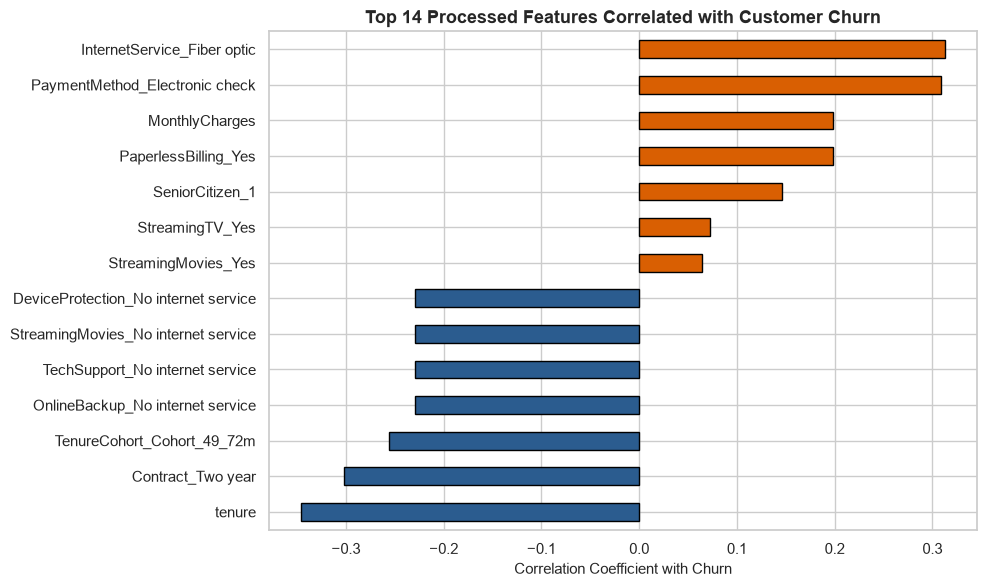

In [8]:
# Convert transformed arrays back to labeled DataFrames
X_train_df = pd.DataFrame(X_train_transformed, columns=all_feature_names)
X_test_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

# Compute correlations with target
train_full = X_train_df.copy()
train_full["Churn"] = y_train.values
target_corrs = train_full.corr()["Churn"].sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
top_corrs = pd.concat([target_corrs.head(7), target_corrs.tail(8).drop("Churn")])
top_corrs.plot(kind="barh", ax=ax, color=np.where(top_corrs > 0, "#d95f02", "#2b5c8f"), edgecolor="black")
ax.set_title("Top 14 Processed Features Correlated with Customer Churn", fontsize=13, weight="bold")
ax.set_xlabel("Correlation Coefficient with Churn")
plt.tight_layout()
plt.show()


---
## 6. Export Processed Datasets for Modeling Handoff
We save the verified, leak-free datasets to `data/processed/` for Phase 3.

In [9]:
output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

X_train_df.to_csv(os.path.join(output_dir, "X_train.csv"), index=False)
X_test_df.to_csv(os.path.join(output_dir, "X_test.csv"), index=False)
y_train.to_csv(os.path.join(output_dir, "y_train.csv"), index=False)
y_test.to_csv(os.path.join(output_dir, "y_test.csv"), index=False)

print(f"[EXPORT SUCCESSFUL] All 4 processed files exported to {output_dir}:")
print(f" - X_train.csv: {X_train_df.shape}")
print(f" - X_test.csv:  {X_test_df.shape}")
print(f" - y_train.csv: {y_train.shape}")
print(f" - y_test.csv:  {y_test.shape}")


[EXPORT SUCCESSFUL] All 4 processed files exported to ../data/processed:
 - X_train.csv: (5634, 35)
 - X_test.csv:  (1409, 35)
 - y_train.csv: (5634,)
 - y_test.csv:  (1409,)


---
## 7. Preprocessing Decision & Architecture Sign-Off

| Pipeline Stage | Transformation Applied | Visual Proof | Decision Reference |
| :--- | :--- | :--- | :--- |
| Missing Values | Impute `TotalCharges = 0.0` | Section 1 Tenure Bar Chart | **DEC-03** |
| Domain Features | `IsAutomaticPayment`, `ServiceBundleCount`, `TenureCohort` | Section 2 Churn Separation Plots | **DEC-04** |
| Leakage Prevention | 80/20 Stratified Partitioning before fitting | Section 3 Split Integrity Chart | **DEC-05** |
| Scaling | `StandardScaler` ($\mu=0, \sigma=1$) | Section 4 Before/After KDE Curves | **DEC-05** |
| Categorical Encoding | `OneHotEncoder(drop='first')` | Section 4 Feature Matrix Audit | **DEC-05** |
| Class Imbalance | Algorithmic cost weighting (`balanced`) | Section 3 Split Preservation | **DEC-06** |

**Notebook Author Sign-off:**  
H A Wickramathilaka (IT24100427) — Preprocessing & Feature Engineering Pipeline Lead